# Predicting Employee Burnout

## Objective

The goal of this notebook is to build machine learning models that predict employee burnout based on AI usage patterns and work characteristics.

Target variable:
- burnout_score

Models:
- Linear Regression
- Random Forest Regressor

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv(
    "../data/processed/ai_worker_burnout_cleaned.csv"
)

In [7]:
import sklearn

print(sklearn.__version__)

1.9.0


In [8]:
df.shape

(1500, 21)

In [9]:
df.columns.tolist()

['employee_id',
 'job_role',
 'years_experience',
 'education_level',
 'country',
 'industry',
 'company_size',
 'remote_work_type',
 'team_size',
 'salary_usd_k',
 'primary_ai_tool',
 'ai_tools_used_per_day',
 'hours_with_ai_assistance_daily',
 'ai_replaces_my_tasks_pct',
 'ai_adoption_stage',
 'weekly_ai_upskilling_hrs',
 'productivity_score',
 'burnout_score',
 'job_satisfaction_1_5',
 'fear_of_ai_replacement',
 'attrition_risk']

In [13]:
target = "burnout_score"

features = [
    "job_role",
    "years_experience",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "salary_usd_k",
    "primary_ai_tool",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "ai_adoption_stage",
    "weekly_ai_upskilling_hrs",
    "productivity_score",
    "job_satisfaction_1_5",
    "fear_of_ai_replacement"
]

X = df[features]
y = df[target]

In [12]:
numeric_features = [
    "years_experience",
    "salary_usd_k",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs",
    "productivity_score",
    "job_satisfaction_1_5"
]

categorical_features = [
    "job_role",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 17)
(300, 17)


The dataset was split into training and test sets. The models learn patterns from the training data and are evaluated on unseen test data. This helps estimate how well the model generalizes to new observations.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

Categorical variables such as job role, industry and remote work type cannot be used directly by most machine learning models. Therefore, they were transformed using one-hot encoding. Numeric variables were passed through unchanged.

In [22]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "mae": round(mae, 2),
        "rmse": round(rmse, 2),
        "r2": round(r2, 3)
    }

MAE shows the average prediction error in burnout score points.

RMSE also measures prediction error, but gives more weight to larger mistakes.

R² shows how much variance in burnout score is explained by the model. A value closer to 1 indicates better predictive performance.

In [23]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

linear_results

{'model': 'Linear Regression', 'mae': 5.42, 'rmse': 6.67, 'r2': 0.655}

In [24]:
# Random Forest

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                max_depth=8
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

rf_results

{'model': 'Random Forest', 'mae': 5.69, 'rmse': 7.03, 'r2': 0.617}

In [25]:
results = pd.DataFrame(
    [
        linear_results,
        rf_results
    ]
)

results

,model,mae,rmse,r2
0,Linear Regression,5.42,6.67,0.655
1,Random Forest,5.69,7.03,0.617


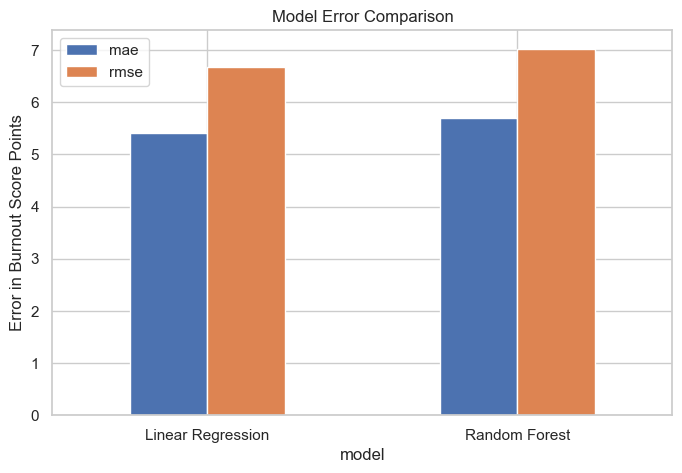

In [26]:
results.set_index("model")[["mae", "rmse"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Error Comparison")
plt.ylabel("Error in Burnout Score Points")
plt.xticks(rotation=0)

plt.show()

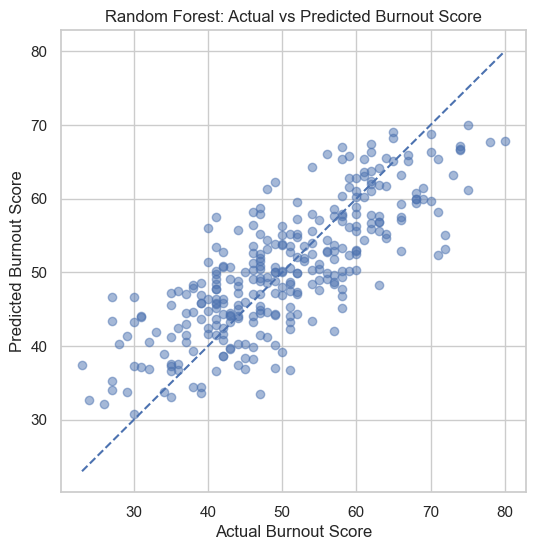

In [27]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Burnout Score")
plt.ylabel("Predicted Burnout Score")
plt.title("Random Forest: Actual vs Predicted Burnout Score")

plt.show()

A basic machine learning section was added as an extension beyond the main data analytics workflow. The goal was to test whether burnout score can be predicted from AI usage patterns, work characteristics and satisfaction indicators.

The Linear Regression model serves as a simple baseline. The Random Forest model is a more flexible model that can capture non-linear relationships between variables.

Surprisingly, the simpler Linear Regression model outperformed the more advanced Random Forest model. This suggests that the relationships between burnout and the selected predictors are largely linear within this dataset.

In [29]:
# AI-only model: using only AI-related variables to predict burnout

ai_features = [
    "primary_ai_tool",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "ai_adoption_stage",
    "weekly_ai_upskilling_hrs",
    "fear_of_ai_replacement"
]

X_ai = df[ai_features]
y = df["burnout_score"]

In [30]:
ai_numeric_features = [
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs"
]

ai_categorical_features = [
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

In [31]:
X_ai_train, X_ai_test, y_ai_train, y_ai_test = train_test_split(
    X_ai,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
ai_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ai_categorical_features
        )
    ],
    remainder="passthrough"
)

In [33]:
ai_linear_model = Pipeline(
    steps=[
        ("preprocessor", ai_preprocessor),
        ("model", LinearRegression())
    ]
)

ai_linear_model.fit(X_ai_train, y_ai_train)

y_pred_ai_linear = ai_linear_model.predict(X_ai_test)

In [34]:
ai_linear_results = evaluate_model(
    y_ai_test,
    y_pred_ai_linear,
    "Linear Regression - AI features only"
)

ai_linear_results

{'model': 'Linear Regression - AI features only',
 'mae': 6.16,
 'rmse': 7.53,
 'r2': 0.56}

In [35]:
results_extended = pd.DataFrame(
    [
        linear_results,
        rf_results,
        ai_linear_results
    ]
)

results_extended

,model,mae,rmse,r2
0,Linear Regression,5.42,6.67,0.655
1,Random Forest,5.69,7.03,0.617
2,Linear Regression - AI features only,6.16,7.53,0.560


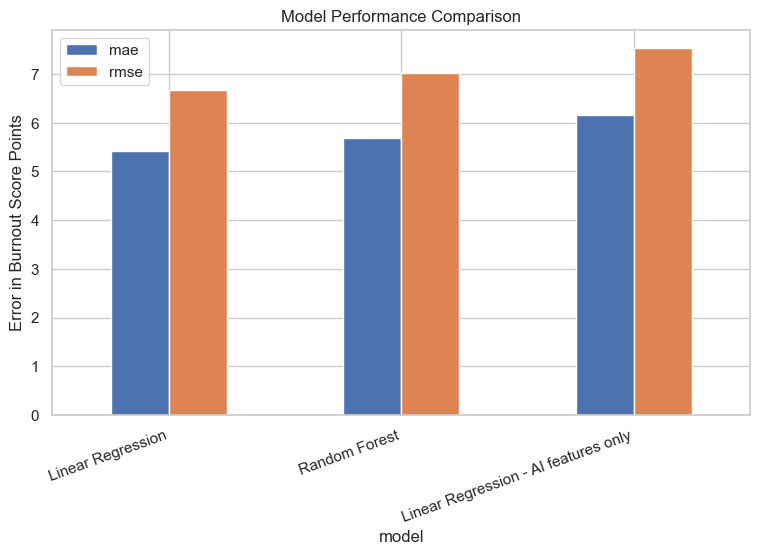

In [36]:
results_extended.set_index("model")[["mae", "rmse"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error in Burnout Score Points")
plt.xticks(rotation=20, ha="right")

plt.show()

The AI-only Linear Regression model was created to test how much of employee burnout can be explained by AI-related variables alone. Comparing this model with the full-feature model helps evaluate whether burnout is mainly associated with AI usage patterns or whether broader work-related variables are also important.

The AI-only model achieved an R² score of 0.560, indicating that AI-related variables alone explain a substantial proportion of the variation in employee burnout scores.

When additional workplace and demographic variables were included, model performance increased to an R² of 0.655. This suggests that while traditional work factors remain important, AI-related variables are already highly informative predictors of burnout.

The relatively small improvement from adding all remaining variables highlights the significant role of AI adoption, usage intensity, task automation, upskilling requirements and replacement concerns in employee wellbeing.


In [37]:
feature_names = (
    linear_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names[:10]

array(['cat__job_role_AI Ethics Officer', 'cat__job_role_AI Researcher',
       'cat__job_role_Backend Engineer', 'cat__job_role_Cloud Architect',
       'cat__job_role_Data Analyst', 'cat__job_role_Data Scientist',
       'cat__job_role_DevOps Engineer', 'cat__job_role_Frontend Engineer',
       'cat__job_role_ML Engineer', 'cat__job_role_Product Manager'],
      dtype=object)

In [38]:
coefficients = (
    linear_model.named_steps["model"]
    .coef_
)

In [39]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,cat__job_role_AI Ethics Officer,-1.267857
1,cat__job_role_AI Researcher,-0.279757
2,cat__job_role_Backend Engineer,0.679538
3,cat__job_role_Cloud Architect,-0.264392
4,cat__job_role_Data Analyst,0.846397


In [40]:
coef_df.sort_values(
    "coefficient",
    ascending=False
).head(15)

,feature,coefficient
63,remainder__hours_with_ai_assistance_daily,1.469360
47,cat__primary_ai_tool_Cursor,1.039853
5,cat__job_role_Data Scientist,0.848719
4,cat__job_role_Data Analyst,0.846397
24,cat__country_Singapore,0.760392
31,cat__industry_EdTech,0.726860
16,cat__education_level_Self-taught,0.724826
18,cat__country_Brazil,0.703875
2,cat__job_role_Backend Engineer,0.679538
30,cat__industry_E-commerce,0.560746


In [41]:
coef_df.sort_values(
    "coefficient",
    ascending=True
).head(15)

,feature,coefficient
67,remainder__job_satisfaction_1_5,-7.001570
0,cat__job_role_AI Ethics Officer,-1.267857
26,cat__country_USA,-1.246299
28,cat__industry_Consulting,-0.973320
27,cat__industry_Automotive,-0.909070
22,cat__country_India,-0.842873
49,cat__primary_ai_tool_GitHub Copilot,-0.711154
10,cat__job_role_Prompt Engineer,-0.650367
25,cat__country_UK,-0.583378
29,cat__industry_Cybersecurity,-0.481492


In [42]:
coef_df["abs_coef"] = coef_df["coefficient"].abs()

top_features = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    .head(10)
)

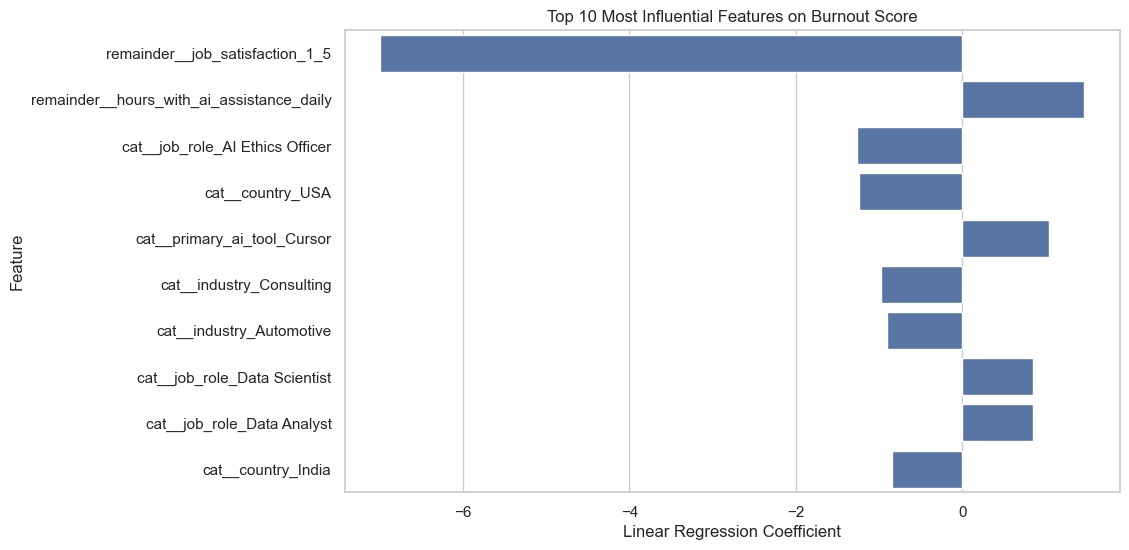

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature"
)

plt.title("Top 10 Most Influential Features on Burnout Score")
plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [45]:
features_no_satisfaction = [
    col for col in features
    if col != "job_satisfaction_1_5"
]

X_ns = df[features_no_satisfaction]
y = df["burnout_score"]


In [47]:
numeric_ns_features = [
    "years_experience",
    "salary_usd_k",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs",
    "productivity_score"
]

categorical_ns_features = [
    "job_role",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

In [46]:
X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(
    X_ns,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
ns_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_ns_features
        )
    ],
    remainder="passthrough"
)

In [49]:
ns_linear_model = Pipeline(
    steps=[
        ("preprocessor", ns_preprocessor),
        ("model", LinearRegression())
    ]
)

ns_linear_model.fit(X_ns_train, y_ns_train)

y_pred_ns_linear = ns_linear_model.predict(X_ns_test)

In [50]:
ns_linear_results = evaluate_model(
    y_ns_test,
    y_pred_ns_linear,
    "Linear Regression - without Job Satisfaction"
)

ns_linear_results

{'model': 'Linear Regression - without Job Satisfaction',
 'mae': 6.19,
 'rmse': 7.53,
 'r2': 0.56}